In [1]:
## Env: allcools
%load_ext autoreload
%autoreload 1
%aimport plot_help
import PyComplexHeatmap as pch
import matplotlib as mpl

# --- Core config ---
mpl.rcParams['pdf.fonttype'] = 42     
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['svg.fonttype'] = 'none' 
mpl.rcParams['figure.dpi']   = 300  
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['savefig.transparent'] = True

mpl.rcParams['path.simplify'] = False

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import pyranges as pr
import matplotlib.pyplot as plt
import cooler
import re
import schicluster
PACKAGE_DIR = schicluster.__path__[0]
from plot_help import *

In [3]:
cellID_merged = pd.read_csv('/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/meta_file/metadata_passQC_05212026.tsv.gz',sep = '\t',index_col=0)
cellID_merged['cluster_L3'] = (
    cellID_merged['age_groups'].astype(str) + '_' +
    cellID_merged['L1'].astype(str)+ '-' + cellID_merged['L2'].astype(str)+ '-' + cellID_merged['L3'].astype(str)
)
cellID_merged['age_L2'] = (
    cellID_merged['age_groups'].astype(str) + '_' +
    cellID_merged['L1'].astype(str)+ '-' + cellID_merged['L2'].astype(str)
)

/tmp/ipykernel_346524/454149414.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  cellID_merged = pd.read_csv('/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/meta_file/metadata_passQC_05212026.tsv.gz',sep = '\t',index_col=0)


In [4]:
geneRef = pd.read_csv('/cndd2/hex002/Luo_Development/genecode.v33.bed', sep='\t', header=None,names = ['chrom','start','end','strand','gene_ID','gene_type','gene_name'])
geneRef.set_index('gene_name',inplace=True)
geneRef['TSS'] = np.where(
    geneRef['strand'] == '+',
    geneRef['start'],
    geneRef['end']
)

geneRef['TES'] = np.where(
    geneRef['strand'] == '+',
    geneRef['end'],
    geneRef['start']
)

## Call differential

In [5]:
indir = '/cndd2/hex002/Luo_Development/hic_domain/'
res = 25000

In [6]:
chrom_size_path = '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hg38.chrom_1-22.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)

## Age_L2

In [7]:
indir = '/cndd2/hex002/Luo_Development/hic_domain/age_L2_bulk/'
bound_count_ct = pd.read_hdf(f'{indir}age_L2_boundcount.hdf', key='data')
cell_count_ct = pd.read_csv(f'{indir}age_L2_cellcount.csv.gz', index_col=0, header=0)
bound_prob_ct = (bound_count_ct.div(cell_count_ct.squeeze(), axis=0))
ins_count = xr.open_dataset(f'/cndd2/hex002/Luo_Development/hic_domain/age_L2_bulk/age_L2_bulk.insulation.nc')
ins_count = ins_count.sel({'bin': (ins_count['bin_chrom']!='chrX')})
ins_count['ratio'] = (ins_count.sel({'type':'inter'})['__xarray_dataarray_variable__'] / ins_count.sel({'type':'intra'}))['__xarray_dataarray_variable__']
cellID_filtered = cellID_merged.groupby('age_L2').filter(lambda x: len(x) > 50)
res = 25000
binall = ins_count[['bin_chrom', 'bin_start', 'bin_end']].to_pandas()
binall.columns = binall.columns.str.split('_').str[1]
binall.index = binall['chrom'] + '_' + (binall['start'] // res).astype(str)
binall.shape

(115009, 3)

In [8]:
stage_order = ["2T", "3T", "1m", "4-7m", "adult"]

legs = {}
pairwise_jobs = {}

for base in {x.split("_", 1)[1] for x in cellID_filtered['age_L2'].unique()}:
    traj = [f"{s}_{base}" for s in stage_order if f"{s}_{base}" in cellID_filtered['age_L2'].values]
    if len(traj) < 2:
        continue

    # full trajectory
    legs[f"dev_{base}"] = traj

    # consecutive pairs
    for a, b in zip(traj, traj[1:]):
        pairwise_jobs[f"dev_{base}__{a.split('_')[0]}-vs-{b.split('_')[0]}"] = [a, b]

In [9]:
# from datetime import datetime
# def run_one_leg(name, leg):
#     try:
#         print(f"[{datetime.now()}] start {name} ({len(leg)} groups)")
#         domain_anova(
#             leg,
#             ins_count=ins_count,
#             bound_count_ct=bound_count_ct,
#             bound_prob_ct=bound_prob_ct,
#             cell_count_ct=cell_count_ct,
#             binall=binall,
#             outdir = '/cndd2/hex002/Luo_Development/hic_domain/anova_test/age_L2_paired',
#             fname = name,
#             save=True
#         )
#         print(f"[{datetime.now()}] done  {name}")
#         return (name, "ok", None)
#     except Exception as e:
#         print(f"[{datetime.now()}] FAIL {name}: {e}")
#         return (name, "fail", str(e))

# # adjust n_jobs to your memory budget (start low if OOM)
# n_jobs = 26
# results = Parallel(n_jobs=n_jobs, prefer="processes", backend="loky")(
#     delayed(run_one_leg)(name, leg) for name, leg in pairwise_jobs.items()
# )

In [10]:
outdir = '/cndd2/hex002/Luo_Development/hic_domain/anova_test/age_L2_paired/'

rows = []  # will store: base, pair, count
for name, leg in pairwise_jobs.items():

    base = name.split("dev_", 1)[1].split("__", 1)[0]
    pair = name.split("__", 1)[1]  

    fpath = os.path.join(outdir, f"{name}_bin_stats.hdf")
    if not os.path.exists(fpath):
        # print(f"[SKIP] {name} (no file)")
        continue

    df = pd.read_hdf(fpath)
    sel = (df['chi2filter']) & (df['probdiff'] > 0.05) & (df['diff_sc'])
    if len(leg) == 2:
        up_sel = (df['chi2filter']) & (df['probdiff'] > 0.05) & (df['diff_sc']) & (df['probdiff_signed'] < 0)
        down_sel = (df['chi2filter']) & (df['probdiff'] > 0.05) & (df['diff_sc']) & (df['probdiff_signed'] > 0)
        rows.append({"base": base, "pair": pair, "count": int(sel.sum()), 'up_count': int(up_sel.sum()), 'down_count': int(down_sel.sum())})
    else:
        rows.append({"base": base, "pair": pair, "count": int(sel.sum())})

# Build table with both per-pair and per-base summaries
count_df = pd.DataFrame(rows)

In [11]:
count_df = count_df[count_df['base'] != 'Exc-DG']
count_df = count_df[count_df['base'] != 'Exc-RG-1']

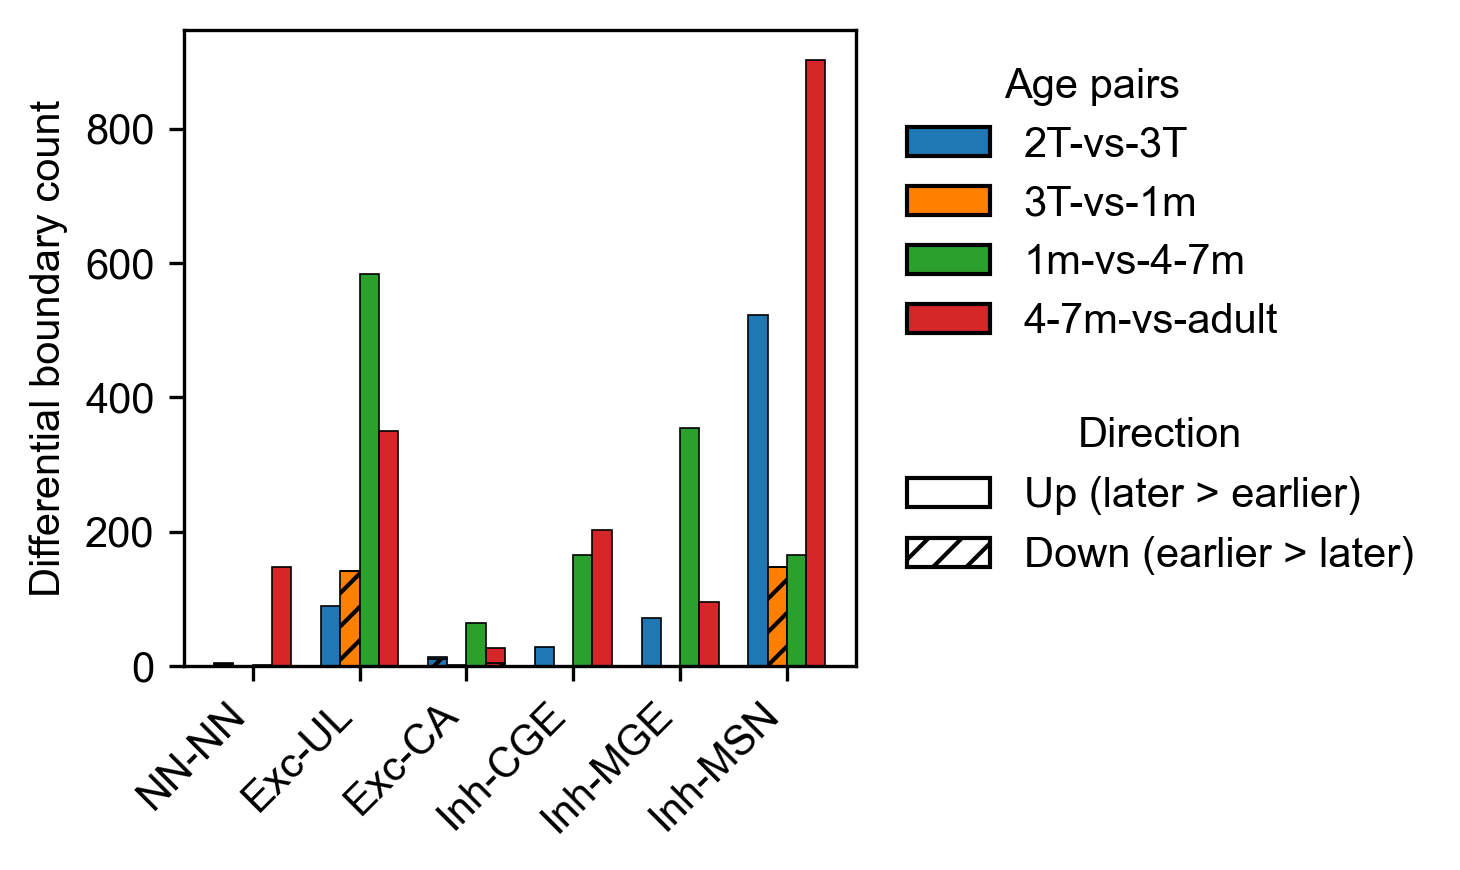

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

desired_order = [
    "NN", "ODC", "OPC", "Astro", "GPC", "RG",
    "UL", "DL-ENT", "CA", "DG", "CGE", "MGE", "MSN"
]
order_map = {name: i for i, name in enumerate(desired_order)}

def extract_suffix(base):
    return base.split("-", 1)[1] if "-" in base else base


bases_unsorted = (
    count_df.groupby("base")["count"]
    .sum()
    .index
    .tolist()
)

bases = sorted(
    bases_unsorted,
    key=lambda b: order_map.get(extract_suffix(b), 999)
)

# ---------------------------------------------------------
# 3. Define pair order
# ---------------------------------------------------------
pairs = ["2T-vs-3T", "3T-vs-1m", "1m-vs-4-7m", "4-7m-vs-adult"]
pairs = [p for p in pairs if p in count_df["pair"].unique()]

# ---------------------------------------------------------
# 4. Pivot in sorted base order
# ---------------------------------------------------------
Pup = (
    count_df.pivot_table(index="base", columns="pair",
                         values="up_count", aggfunc="sum")
    .fillna(0)
    .reindex(index=bases, columns=pairs)
)

Pdown = (
    count_df.pivot_table(index="base", columns="pair",
                         values="down_count", aggfunc="sum")
    .fillna(0)
    .reindex(index=bases, columns=pairs)
)

# ---------------------------------------------------------
# 5. Plot
# ---------------------------------------------------------
x = np.arange(len(bases))
bar_width = 0.18
pair_colors = ["#1f77b4", "#ff8000", "#2ca02c", "#d62728"][:len(pairs)]

fig, ax = plt.subplots(figsize=(min(5, len(bases)*1.2), 3))

for i, pair in enumerate(pairs):
    xpos = x + i * bar_width

    down_vals = Pdown[pair].values
    up_vals = Pup[pair].values

    # DOWN
    ax.bar(
        xpos,
        down_vals,
        width=bar_width,
        color=pair_colors[i],
        hatch="///",
        edgecolor="black",
        linewidth=0.4
    )

    # UP
    ax.bar(
        xpos,
        up_vals,
        width=bar_width,
        bottom=down_vals,
        color=pair_colors[i],
        hatch=None,
        edgecolor="black",
        linewidth=0.4
    )

# ---- Axis ----
ax.set_ylabel("Differential boundary count")
ax.set_xticks(x + bar_width*(len(pairs)-1)/2)
ax.set_xticklabels(bases, rotation=45, ha='right')

# ---- Legends ----
pair_legend_handles = [
    Patch(facecolor=pair_colors[i], edgecolor="black", label=pairs[i])
    for i in range(len(pairs))
]
legend1 = ax.legend(handles=pair_legend_handles,
                    title="Age pairs",
                    frameon=False,
                    loc="upper left",
                    bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)

direction_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=None,
          label="Up (later > earlier)"),
    Patch(facecolor="white", edgecolor="black", hatch="///",
          label="Down (earlier > later)")
]
ax.legend(handles=direction_handles,
          title="Direction",
          frameon=False,
          loc="upper left",
          bbox_to_anchor=(1.02, 0.45))

plt.tight_layout()
# plt.savefig('/cndd2/hex002/Luo_Development/hic_domain/anova_test/age_L2_paired/age_L2_pairwise_diff_boundary_counts.pdf', dpi=300)
plt.show()

## SPN example

In [13]:
indir = '/cndd2/hex002/Luo_Development/hic_domain/'
outdir = '/cndd2/hex002/Luo_Development/hic_domain/anova_test/age_L3_paired/'
bound_count_ct = pd.read_hdf(f'{indir}age_L3_bulk/age_L3_boundcount.hdf', key='data')
cell_count_ct = pd.read_csv(f'{indir}age_L3_bulk/age_L3_cellcount.csv.gz', index_col=0, header=0)
bound_prob_ct = (bound_count_ct.div(cell_count_ct.squeeze(), axis=0))
ins_count = xr.open_dataset(f'{indir}age_L3_bulk/age_L3_bulk.insulation.nc')
ins_count['ratio'] = (ins_count.sel({'type':'inter'})['__xarray_dataarray_variable__'] / ins_count.sel({'type':'intra'}))['__xarray_dataarray_variable__']
res = 25000
binall = ins_count[['bin_chrom', 'bin_start', 'bin_end']].to_pandas()
binall.columns = binall.columns.str.split('_').str[1]
binall.index = binall['chrom'] + '_' + (binall['start'] // res).astype(str)
binall.shape

(115009, 3)

In [14]:
MSN_DRD1_EPHA4_linage = ['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-EPHA4','3T_Inh-MSN-DRD1-EPHA4','1m_Inh-MSN-DRD1-EPHA4','4-7m_Inh-MSN-DRD1-EPHA4','adult_Inh-MSN-DRD1-EPHA4']
MSN_DRD1_BACH2_linage = ['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-BACH2','3T_Inh-MSN-DRD2-BACH2','1m_Inh-MSN-DRD2-BACH2','4-7m_Inh-MSN-DRD2-BACH2','adult_Inh-MSN-DRD2-BACH2']
MSN_DRD2_EPHA4_linage = ['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD2-EPHA4','3T_Inh-MSN-DRD2-EPHA4','1m_Inh-MSN-DRD2-EPHA4','4-7m_Inh-MSN-DRD2-EPHA4','adult_Inh-MSN-DRD2-EPHA4']
MSN_DRD2_BACH2_linage = ['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD2-BACH2','3T_Inh-MSN-DRD2-BACH2','1m_Inh-MSN-DRD2-BACH2','4-7m_Inh-MSN-DRD2-BACH2','adult_Inh-MSN-DRD2-BACH2']
MSN_2T = ['2T_Inh-MSN-DRD2-EPHA4','2T_Inh-MSN-DRD2-BACH2']
MSN_3T = ['3T_Inh-MSN-DRD2-EPHA4','3T_Inh-MSN-DRD2-BACH2']
MSN_2T_eMSN_EPHA4 = ['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-EPHA4']
MSN_3T_eMSN_EPHA4 = ['2T_Inh-MSN-eMSN','3T_Inh-MSN-DRD1-EPHA4']
lineages = {
    "MSN_DRD1-EPHA4": MSN_DRD1_EPHA4_linage,
    "MSN_DRD1-BACH2": MSN_DRD1_BACH2_linage,
    "MSN_DRD2-EPHA4": MSN_DRD2_EPHA4_linage,
    "MSN_DRD2-BACH2": MSN_DRD2_BACH2_linage,
    "MSN_2T": MSN_2T,
    "MSN_3T": MSN_3T,
    '2T_eMSN_EPHA4': MSN_2T_eMSN_EPHA4,
    '3T_eMSN_EPHA4': MSN_3T_eMSN_EPHA4
}


In [15]:
outdir = '/cndd2/hex002/Luo_Development/hic_domain/anova_test/L3_age/'
name = '2T_eMSN_EPHA4'
leg = lineages[name]
fpath = os.path.join(outdir, f"{name}_bin_stats.hdf")
leg_binall = pd.read_hdf(fpath)
sel = leg_binall['chi2filter'] & leg_binall['ins_lm'] & (leg_binall['probdiff'] > 0.05) & leg_binall['diff_sc']
leg_binall_sig = leg_binall[sel]#.sort_values('insfc', ascending=False).head(100)

In [16]:
chrom, start, end, _, gene_ID, gene_type,TSS,TES = geneRef.loc['EBF1']
print(chrom, start, end,_,TSS,TES)
bin_index = f'{chrom}_{start//25_000}'  

chr5 158695916 159099916 - 159099916 158695916


/cndd2/hex002/Luo_Development/2026_BasalGanglia_m3C/HiC_analysis/Domain/plot_help.py:454: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


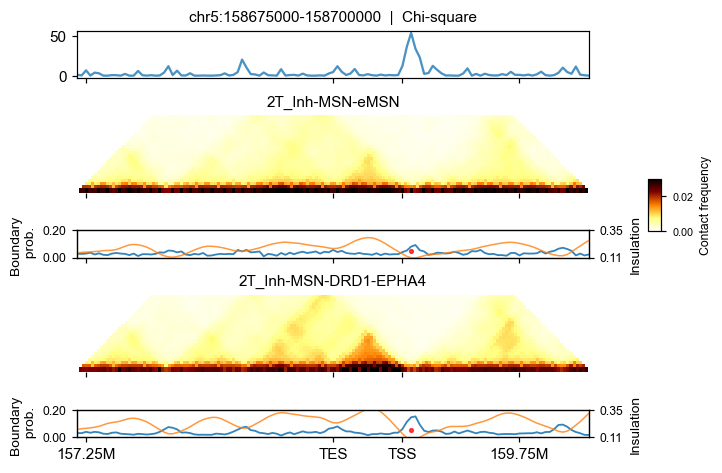

In [17]:
fig, axes = plot_domain_window(
    bin_id=bin_index,
    leg_binall = leg_binall,
    leg = leg,
    vmax = 0.03, 
    ins_count =ins_count,
    lslop = 1_500_000,
    rslop = 1_500_000,
    binall=leg_binall,
    bound_prob_ct=bound_prob_ct,
    marker_track="diff_sc",
    annotation = {'TSS':TSS, 'TES':TES}
                #   '89.43M':89430000,
                #   '90.8M':90800000}   
)
# plt.savefig('2T_eMSN_DRD1-EPHA4.pdf', dpi=300)
# plt.savefig('MSN_DRD1-EPHA4_linage_FOXP1.pdf', dpi=300)
# plt.savefig('MSN_DRD1-BACH2_linage_BACH2.pdf', dpi=300)